# Pre-Match Baseline Models

**Objective:** Build models that predict match outcomes using only information available *before kickoff* — no in-match events.  
This establishes a **minute-zero baseline** to compare against time-bucketed in-match models (15/30/45/60/75/90 min).

## Models Built
1. **ELO Rating System**: Rolling team strength ratings computed from match history
2. **Pre-Match Logistic Regression**: Predict win/loss from ELO diff, home advantage, competition
3. **Poisson Goal Model**: Predict scorelines from team attack/defense strength ratings

---

In [13]:
#import
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

---
## 1. Data Loading & Preprocessing

In [2]:
#data

PROJECT_ROOT = Path.cwd().parent  # assumes notebook is in /eda
STATSBOMB_DIR = PROJECT_ROOT / 'data' / 'Statsbomb'

matches_df = pd.read_parquet(STATSBOMB_DIR / 'matches.parquet')
print(f'Raw matches: {matches_df.shape[0]}')

# Parse date and extract year
matches_df['match_date'] = pd.to_datetime(matches_df['match_date'], errors='coerce')
matches_df['year'] = matches_df['match_date'].dt.year

# Filter: men's, non-youth, post-2000
matches_df = matches_df[
    (matches_df['gender'] == 'male') &
    (matches_df['is_youth'] == False) &
    (matches_df['year'] >= 2000)
].copy()

# Sort chronologically (critical for ELO)
matches_df = matches_df.sort_values('match_date').reset_index(drop=True)

# Derive result columns
matches_df['home_win'] = (matches_df['home_score'] > matches_df['away_score']).astype(int)
matches_df['away_win'] = (matches_df['away_score'] > matches_df['home_score']).astype(int)
matches_df['draw'] = (matches_df['home_score'] == matches_df['away_score']).astype(int)
matches_df['total_goals'] = matches_df['home_score'] + matches_df['away_score']

print(f'Filtered matches: {matches_df.shape[0]}')
print(f'Date range: {matches_df["match_date"].min()} to {matches_df["match_date"].max()}')
print(f'\nResult distribution:')
print(f'  Home wins: {matches_df["home_win"].sum()} ({matches_df["home_win"].mean():.1%})')
print(f'  Away wins: {matches_df["away_win"].sum()} ({matches_df["away_win"].mean():.1%})')
print(f'  Draws:     {matches_df["draw"].sum()} ({matches_df["draw"].mean():.1%})')
print(f'\nAvg goals/match: {matches_df["total_goals"].mean():.2f}')
display(matches_df.head())

Raw matches: 3464
Filtered matches: 2889
Date range: 2003-08-16 00:00:00 to 2024-07-15 00:00:00

Result distribution:
  Home wins: 1282 (44.4%)
  Away wins: 901 (31.2%)
  Draws:     706 (24.4%)

Avg goals/match: 2.82


,match_id,match_date,match_week,match_status,match_status_360,kickoff,home_score,away_score,competition_id,competition,competition_stage,season_id,season,home_team_id,home_team,home_managers,away_team_id,away_team,away_managers,stadium_id,stadium,referee_id,referee,last_updated,last_updated_360,data_version,shot_fidelity_version,xy_fidelity_version,competition_name,gender,is_youth,is_international,country_name,season_name,match_updated,match_available_360,year,home_win,away_win,draw,total_goals
0,3749493,2003-08-16,1,available,scheduled,16:00:00,2,1,2,Premier League,Regular Season,44,2003/2004,1,Arsenal,"[{""id"":577,""name"":""Arsène Wenger"",""nickname"":n...",29,Everton,"[{""id"":86,""name"":""David Moyes"",""nickname"":null...",1000243.0,Highbury Stadium,NaN,None,2020-07-29T05:00,2021-06-13T16:17:31.694,1.1.0,2,2,Premier League,male,False,False,England,2003/2004,2025-06-24T13:53:07.585114,None,2003,1,0,0,3
1,3749358,2003-08-24,1,available,scheduled,17:05:00,0,4,2,Premier League,Regular Season,44,2003/2004,47,Middlesbrough,"[{""id"":40,""name"":""Steve McClaren"",""nickname"":n...",1,Arsenal,"[{""id"":577,""name"":""Arsène Wenger"",""nickname"":n...",214.0,Riverside Stadium,NaN,None,2020-07-29T05:00,2021-06-13T16:17:31.694,1.1.0,2,2,Premier League,male,False,False,England,2003/2004,2025-06-24T13:53:07.585114,None,2003,0,1,0,4
2,3749108,2003-08-27,3,available,processing,20:45:00,2,0,2,Premier League,Regular Season,44,2003/2004,1,Arsenal,"[{""id"":577,""name"":""Arsène Wenger"",""nickname"":n...",59,Aston Villa,"[{""id"":6094,""name"":""David O''Leary"",""nickname""...",NaN,None,NaN,None,2023-01-28T22:32:37.443603,2021-06-12T16:17:31.694,1.1.0,2,2,Premier League,male,False,False,England,2003/2004,2025-06-24T13:53:07.585114,None,2003,1,0,0,2
3,3749454,2003-08-31,1,available,scheduled,17:05:00,1,2,2,Premier League,Regular Season,44,2003/2004,36,Manchester City,"[{""id"":4202,""name"":""Kevin Joseph Keegan"",""nick...",1,Arsenal,"[{""id"":577,""name"":""Arsène Wenger"",""nickname"":n...",4715.0,Etihad Stadium,NaN,None,2020-07-29T05:00,2021-06-13T16:17:31.694,1.1.0,2,2,Premier League,male,False,False,England,2003/2004,2025-06-24T13:53:07.585114,None,2003,0,1,0,3
4,3749296,2003-09-13,5,available,scheduled,16:00:00,1,1,2,Premier League,Regular Season,44,2003/2004,1,Arsenal,"[{""id"":577,""name"":""Arsène Wenger"",""nickname"":n...",105,Portsmouth,"[{""id"":749,""name"":""Harry Redknapp"",""nickname"":...",1000243.0,Highbury Stadium,NaN,None,2020-07-29T05:00,2021-06-13T16:17:31.694,1.1.0,2,2,Premier League,male,False,False,England,2003/2004,2025-06-24T13:53:07.585114,None,2003,0,0,1,2


---
## 2. ELO Rating System

We compute rolling ELO ratings for every team from chronological match history.  
- Starting ELO: **1500** for all teams  
- K-factor: **20** (standard for soccer)  
- Draw handling: Both teams treated as 0.5 result  
- Each match records the **pre-match** ELO for both teams before updating

In [3]:
#ELO rating

def compute_elo_ratings(matches, k=20, initial_elo=1500):
    """
    Compute rolling ELO ratings from chronological match history.
    Returns the matches dataframe with pre-match ELO columns added.
    """
    elo = {}  # team -> current ELO
    
    home_elos = []
    away_elos = []
    
    for _, row in matches.iterrows():
        home = row['home_team']
        away = row['away_team']
        
        # Initialize if first appearance
        if home not in elo:
            elo[home] = initial_elo
        if away not in elo:
            elo[away] = initial_elo
        
        # Record pre-match ELO
        home_elos.append(elo[home])
        away_elos.append(elo[away])
        
        # Expected scores
        exp_home = 1 / (1 + 10 ** ((elo[away] - elo[home]) / 400))
        exp_away = 1 - exp_home
        
        # Actual scores
        if row['home_score'] > row['away_score']:
            actual_home, actual_away = 1.0, 0.0
        elif row['home_score'] < row['away_score']:
            actual_home, actual_away = 0.0, 1.0
        else:
            actual_home, actual_away = 0.5, 0.5
        
        # Update ELOs
        elo[home] += k * (actual_home - exp_home)
        elo[away] += k * (actual_away - exp_away)
    
    matches = matches.copy()
    matches['home_elo'] = home_elos
    matches['away_elo'] = away_elos
    matches['elo_diff'] = matches['home_elo'] - matches['away_elo']
    
    return matches, elo

matches_df, final_elos = compute_elo_ratings(matches_df)

print(f'ELO ratings computed for {len(final_elos)} teams')
print(f'\nELO diff stats:')
print(matches_df['elo_diff'].describe().round(1))

ELO ratings computed for 235 teams

ELO diff stats:
count    2889.0
mean        0.6
std       129.0
min      -387.1
25%       -44.2
50%         0.0
75%        45.8
max       396.8
Name: elo_diff, dtype: float64


Top 15 teams by final ELO:
Real Madrid            1722.8
Barcelona              1714.7
Bayer Leverkusen       1710.6
Paris Saint-Germain    1693.4
Juventus               1653.0
Atlético Madrid        1652.5
Bayern Munich          1651.9
Arsenal                1630.3
AS Roma                1630.2
Leicester City         1627.0
Borussia Dortmund      1622.0
Napoli                 1615.7
Spain                  1590.6
France                 1586.2
Jamshedpur             1573.8

Bottom 10 teams by final ELO:
Eibar               1433.7
NorthEast United    1432.5
Levante UD          1426.2
East Bengal         1420.6
Hellas Verona       1415.8
Norwich City        1413.1
Frosinone           1405.3
Hannover 96         1400.9
Troyes              1366.7
Aston Villa         1342.3


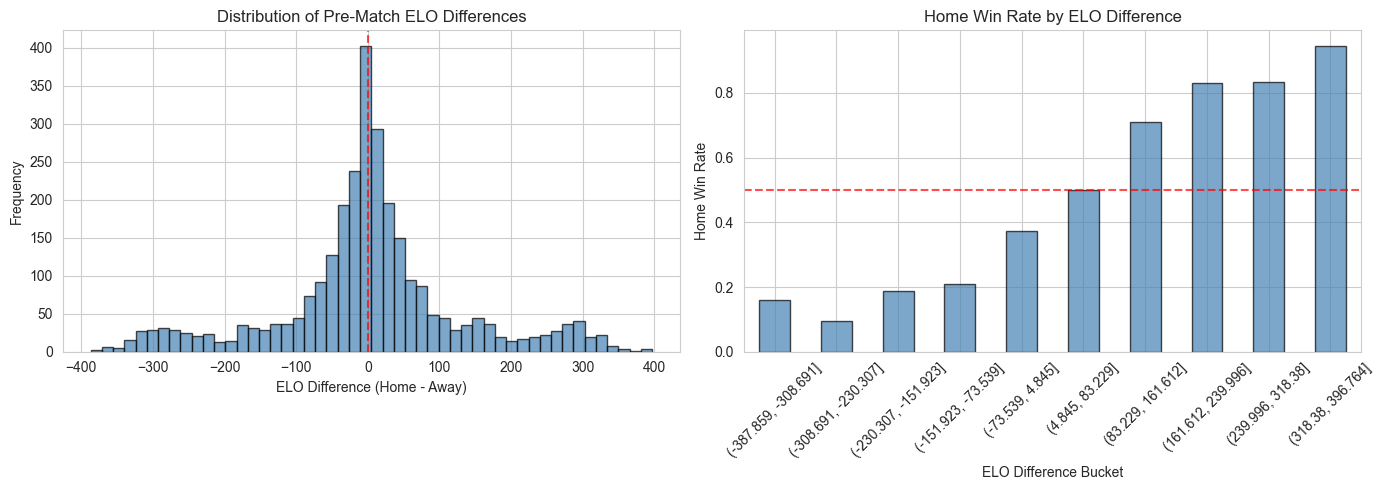

In [4]:
#Top teams

# Top/Bottom teams by final ELO
elo_ranking = pd.Series(final_elos).sort_values(ascending=False)
print('Top 15 teams by final ELO:')
print(elo_ranking.head(15).round(1).to_string())
print(f'\nBottom 10 teams by final ELO:')
print(elo_ranking.tail(10).round(1).to_string())

# Plot ELO diff distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(matches_df['elo_diff'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('ELO Difference (Home - Away)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Pre-Match ELO Differences')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7)

# Win rate by ELO diff bucket
matches_df['elo_diff_bucket'] = pd.cut(matches_df['elo_diff'], bins=10)
win_by_elo = matches_df.groupby('elo_diff_bucket', observed=True)['home_win'].mean()
win_by_elo.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('ELO Difference Bucket')
axes[1].set_ylabel('Home Win Rate')
axes[1].set_title('Home Win Rate by ELO Difference')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.7)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 3. Pre-Match Logistic Regression

Predict **win vs loss** (draws excluded, matching Nick's approach) using only pre-match features:
- `elo_diff` (home ELO - away ELO)
- `is_home` (always 1 in home-perspective rows, captured via ELO diff sign + intercept)
- `competition_name` (encoded)
- `year`

We use **GroupKFold** on `match_id` to prevent leakage (same as Nick's approach).

In [5]:
# Create two rows per match: one from home perspective, one from away
home_rows = matches_df[matches_df['draw'] == 0][[
    'match_id', 'match_date', 'year', 'competition_name',
    'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'home_win'
]].copy()
home_rows.rename(columns={
    'home_team': 'team', 'away_team': 'opponent',
    'home_elo': 'team_elo', 'away_elo': 'opp_elo',
    'home_win': 'win'
}, inplace=True)
home_rows['is_home'] = 1

away_rows = matches_df[matches_df['draw'] == 0][[
    'match_id', 'match_date', 'year', 'competition_name',
    'away_team', 'home_team', 'away_elo', 'home_elo', 'elo_diff', 'away_win'
]].copy()
away_rows.rename(columns={
    'away_team': 'team', 'home_team': 'opponent',
    'away_elo': 'team_elo', 'home_elo': 'opp_elo',
    'away_win': 'win'
}, inplace=True)
away_rows['elo_diff'] = -away_rows['elo_diff']  # from away team's perspective
away_rows['is_home'] = 0

model_df = pd.concat([home_rows, away_rows], ignore_index=True)
model_df['elo_diff_team'] = model_df['team_elo'] - model_df['opp_elo']

print(f'Model dataframe: {model_df.shape[0]} rows ({model_df["match_id"].nunique()} matches, draws excluded)')
print(f'Win rate: {model_df["win"].mean():.3f} (should be ~0.5)')
display(model_df.head())

Model dataframe: 4366 rows (2183 matches, draws excluded)
Win rate: 0.500 (should be ~0.5)


,match_id,match_date,year,competition_name,team,opponent,team_elo,opp_elo,elo_diff,win,is_home,elo_diff_team
0,3749493,2003-08-16,2003,Premier League,Arsenal,Everton,1500.000000,1500.0000,0.000000,1,1,0.000000
1,3749358,2003-08-24,2003,Premier League,Middlesbrough,Arsenal,1500.000000,1510.0000,-10.000000,0,1,-10.000000
2,3749108,2003-08-27,2003,Premier League,Arsenal,Aston Villa,1519.712256,1500.0000,19.712256,1,1,19.712256
3,3749454,2003-08-31,2003,Premier League,Manchester City,Arsenal,1500.000000,1529.1455,-29.145500,0,1,-29.145500
4,3749528,2003-09-26,2003,Premier League,Arsenal,Newcastle United,1536.143498,1500.0000,36.143498,1,1,36.143498


In [6]:
#GROUPED CROSS-VALIDATION

def run_grouped_cv(X, y, groups, model_name, n_splits=5):
    """Run GroupKFold CV and return metrics dataframe."""
    gkf = GroupKFold(n_splits=n_splits)
    model = LogisticRegression(max_iter=1000)
    
    acc_scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring='accuracy')
    auc_scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring='roc_auc')
    
    return pd.DataFrame([{
        'Model': model_name,
        'Accuracy Mean': np.mean(acc_scores),
        'Accuracy StD': np.std(acc_scores),
        'AUC Mean': np.mean(auc_scores),
        'AUC StD': np.std(auc_scores),
    }]).round(3)

groups = model_df['match_id']
results = []

# Model A: ELO diff only
X_elo = model_df[['elo_diff_team']]
y = model_df['win']
results.append(run_grouped_cv(X_elo, y, groups, 'ELO diff only'))

# Model B: ELO diff + home advantage
X_home = model_df[['elo_diff_team', 'is_home']]
results.append(run_grouped_cv(X_home, y, groups, 'ELO diff + Home'))

# Model C: ELO diff + home + competition
comp_dummies = pd.get_dummies(model_df['competition_name'], prefix='comp', drop_first=True)
X_full = pd.concat([model_df[['elo_diff_team', 'is_home']], comp_dummies], axis=1)
results.append(run_grouped_cv(X_full, y, groups, 'ELO diff + Home + Competition'))

# Model D: ELO diff + home + year
X_year = model_df[['elo_diff_team', 'is_home', 'year']]
results.append(run_grouped_cv(X_year, y, groups, 'ELO diff + Home + Year'))

prematch_results = pd.concat(results, ignore_index=True)
print('Pre-Match Logistic Regression Results (GroupKFold CV):')
display(prematch_results)

Pre-Match Logistic Regression Results (GroupKFold CV):


,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,ELO diff only,0.687,0.034,0.763,0.031
1,ELO diff + Home,0.687,0.019,0.778,0.028
2,ELO diff + Home + Competition,0.688,0.019,0.778,0.028
3,ELO diff + Home + Year,0.687,0.019,0.778,0.028


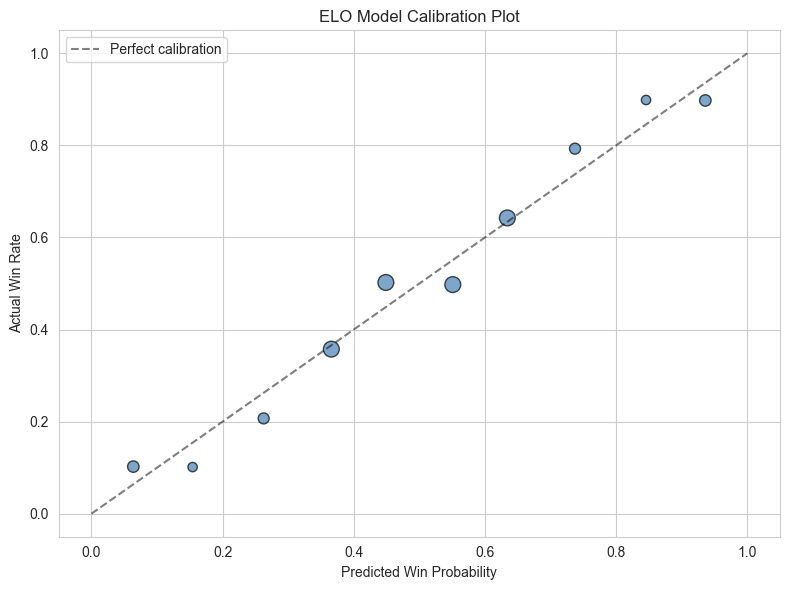

In [7]:
# How well does ELO-predicted probability match actual win rate?

model = LogisticRegression(max_iter=1000)
model.fit(model_df[['elo_diff_team', 'is_home']], model_df['win'])
model_df['pred_prob'] = model.predict_proba(model_df[['elo_diff_team', 'is_home']])[:, 1]

# Bin predicted probabilities and compare to actual win rates
model_df['prob_bucket'] = pd.cut(model_df['pred_prob'], bins=10)
calibration = model_df.groupby('prob_bucket', observed=True).agg(
    pred_mean=('pred_prob', 'mean'),
    actual_mean=('win', 'mean'),
    count=('win', 'size')
).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.scatter(calibration['pred_mean'], calibration['actual_mean'],
           s=calibration['count'] / 5, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Predicted Win Probability')
ax.set_ylabel('Actual Win Rate')
ax.set_title('ELO Model Calibration Plot')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Poisson Goal Model

Predict the **number of goals** each team will score using a Poisson distribution.  
Each team has an **attack rating** (goals scored per game relative to league average) and a **defense rating** (goals conceded per game relative to league average).

Expected goals for home team = `league_avg × home_attack × away_defense × home_advantage`  
Expected goals for away team = `league_avg × away_attack × home_defense`

In [8]:
### === POISSON GOAL MODEL === ###

def build_poisson_ratings(matches, min_games=5):
    """
    Compute attack and defense strength ratings for each team.
    Uses all historical matches up to each match date as training.
    """
    league_avg_home = matches['home_score'].mean()
    league_avg_away = matches['away_score'].mean()
    
    # Team attack strength = (team's avg goals scored) / league avg
    # Team defense strength = (team's avg goals conceded) / league avg
    
    # Home stats
    home_stats = matches.groupby('home_team').agg(
        home_scored=('home_score', 'mean'),
        home_conceded=('away_score', 'mean'),
        home_games=('match_id', 'size')
    )
    
    # Away stats
    away_stats = matches.groupby('away_team').agg(
        away_scored=('away_score', 'mean'),
        away_conceded=('home_score', 'mean'),
        away_games=('match_id', 'size')
    )
    
    # Combine
    teams = set(matches['home_team']) | set(matches['away_team'])
    ratings = {}
    
    for team in teams:
        h = home_stats.loc[team] if team in home_stats.index else None
        a = away_stats.loc[team] if team in away_stats.index else None
        
        total_games = (h['home_games'] if h is not None else 0) + (a['away_games'] if a is not None else 0)
        if total_games < min_games:
            continue
        
        # Weighted average of home and away performance
        scored_parts, conceded_parts, weights = [], [], []
        if h is not None and h['home_games'] > 0:
            scored_parts.append(h['home_scored'] / league_avg_home)
            conceded_parts.append(h['home_conceded'] / league_avg_away)
            weights.append(h['home_games'])
        if a is not None and a['away_games'] > 0:
            scored_parts.append(a['away_scored'] / league_avg_away)
            conceded_parts.append(a['away_conceded'] / league_avg_home)
            weights.append(a['away_games'])
        
        if weights:
            w = np.array(weights) / sum(weights)
            ratings[team] = {
                'attack': np.average(scored_parts, weights=w),
                'defense': np.average(conceded_parts, weights=w),
                'games': total_games
            }
    
    return ratings, league_avg_home, league_avg_away


def poisson_match_probs(home_exp, away_exp, max_goals=7):
    """
    Calculate match outcome probabilities from Poisson expected goals.
    Returns: (home_win_prob, draw_prob, away_win_prob)
    """
    home_probs = [poisson.pmf(i, home_exp) for i in range(max_goals + 1)]
    away_probs = [poisson.pmf(i, away_exp) for i in range(max_goals + 1)]
    
    home_win = sum(home_probs[i] * away_probs[j]
                   for i in range(max_goals + 1)
                   for j in range(i))
    draw = sum(home_probs[i] * away_probs[i]
               for i in range(max_goals + 1))
    away_win = 1 - home_win - draw
    
    return home_win, draw, away_win


# Build ratings from all matches
ratings, avg_home, avg_away = build_poisson_ratings(matches_df)

print(f'Poisson ratings computed for {len(ratings)} teams')
print(f'League avg goals: Home={avg_home:.2f}, Away={avg_away:.2f}')

# Show top teams by attack strength
ratings_df = pd.DataFrame(ratings).T
ratings_df = ratings_df.sort_values('attack', ascending=False)
print(f'\nTop 10 teams by attack strength:')
display(ratings_df.head(10).round(3))
print(f'\nTop 10 teams by defense strength (lower = better):')
display(ratings_df.sort_values('defense').head(10).round(3))

Poisson ratings computed for 172 teams
League avg goals: Home=1.58, Away=1.24

Top 10 teams by attack strength:


,attack,defense,games
Barcelona,1.870,0.592,528.0
Paris Saint-Germain,1.793,0.568,95.0
Real Madrid,1.622,0.948,69.0
Borussia Dortmund,1.611,0.729,37.0
AS Roma,1.558,0.759,38.0
Bayer Leverkusen,1.518,0.666,68.0
Bayern Munich,1.515,0.479,39.0
Spain,1.472,0.646,21.0
Napoli,1.472,0.587,38.0
Hyderabad,1.457,0.828,23.0



Top 10 teams by defense strength (lower = better):


,attack,defense,games
South Africa,0.706,0.270,7.0
Inter Miami,1.093,0.345,6.0
Brazil,1.034,0.423,14.0
Colombia,1.241,0.449,10.0
Cape Verde Islands,1.080,0.449,5.0
Uruguay,0.977,0.468,14.0
Bayern Munich,1.515,0.479,39.0
Juventus,1.381,0.483,40.0
Congo DR,0.591,0.501,7.0
Angola,1.276,0.505,5.0


In [9]:
### === POISSON MODEL EVALUATION === ###
# Predict outcomes for all matches where both teams have ratings

home_advantage = avg_home / avg_away  # home scoring premium

poisson_preds = []
for _, row in matches_df.iterrows():
    h, a = row['home_team'], row['away_team']
    if h not in ratings or a not in ratings:
        continue
    
    home_exp = avg_home * ratings[h]['attack'] * ratings[a]['defense']
    away_exp = avg_away * ratings[a]['attack'] * ratings[h]['defense']
    
    hw, dr, aw = poisson_match_probs(home_exp, away_exp)
    
    # Actual result
    if row['home_score'] > row['away_score']:
        actual = 'H'
    elif row['home_score'] < row['away_score']:
        actual = 'A'
    else:
        actual = 'D'
    
    # Predicted result (highest probability)
    probs = {'H': hw, 'D': dr, 'A': aw}
    predicted = max(probs, key=probs.get)
    
    poisson_preds.append({
        'match_id': row['match_id'],
        'home_team': h, 'away_team': a,
        'home_exp_goals': round(home_exp, 2),
        'away_exp_goals': round(away_exp, 2),
        'prob_home': round(hw, 3),
        'prob_draw': round(dr, 3),
        'prob_away': round(aw, 3),
        'predicted': predicted,
        'actual': actual,
        'correct': predicted == actual
    })

poisson_df = pd.DataFrame(poisson_preds)

print(f'Poisson predictions for {len(poisson_df)} matches')
print(f'Overall accuracy (3-way: H/D/A): {poisson_df["correct"].mean():.3f}')

# Win/loss only accuracy (exclude draws)
wl = poisson_df[poisson_df['actual'] != 'D']
wl_correct = ((wl['actual'] == 'H') & (wl['prob_home'] > wl['prob_away'])) | \
             ((wl['actual'] == 'A') & (wl['prob_away'] > wl['prob_home']))
print(f'Win/Loss accuracy (excl draws): {wl_correct.mean():.3f}')

# AUC for home win prediction (binary)
wl_binary = wl.copy()
wl_binary['actual_home_win'] = (wl_binary['actual'] == 'H').astype(int)
# Normalize home/away probs to sum to 1 (excluding draw)
wl_binary['home_win_prob_norm'] = wl_binary['prob_home'] / (wl_binary['prob_home'] + wl_binary['prob_away'])
poisson_auc = roc_auc_score(wl_binary['actual_home_win'], wl_binary['home_win_prob_norm'])
print(f'AUC (home win, excl draws): {poisson_auc:.3f}')

display(poisson_df.head(10))

Poisson predictions for 2740 matches
Overall accuracy (3-way: H/D/A): 0.561
Win/Loss accuracy (excl draws): 0.743
AUC (home win, excl draws): 0.824


,match_id,home_team,away_team,home_exp_goals,away_exp_goals,prob_home,prob_draw,prob_away,predicted,actual,correct
0,3749493,Arsenal,Everton,2.17,0.76,0.695,0.186,0.120,H,H,True
1,3749108,Arsenal,Aston Villa,2.94,0.34,0.879,0.086,0.035,H,H,True
2,3749454,Manchester City,Arsenal,1.14,1.31,0.325,0.272,0.403,A,A,True
3,3749552,Manchester United,Arsenal,0.79,1.05,0.268,0.320,0.412,A,D,False
4,3749528,Arsenal,Newcastle United,2.43,0.56,0.784,0.146,0.070,H,H,True
5,3749253,Liverpool,Arsenal,1.09,1.63,0.254,0.246,0.500,A,A,True
6,3749079,Arsenal,Chelsea,2.12,0.77,0.686,0.190,0.124,H,H,True
7,3749196,Arsenal,Tottenham Hotspur,1.47,0.89,0.506,0.265,0.229,H,H,True
8,3749590,Leicester City,Arsenal,1.14,1.13,0.359,0.286,0.354,H,D,False
9,3749310,Southampton,Arsenal,0.92,1.28,0.268,0.285,0.447,A,A,True


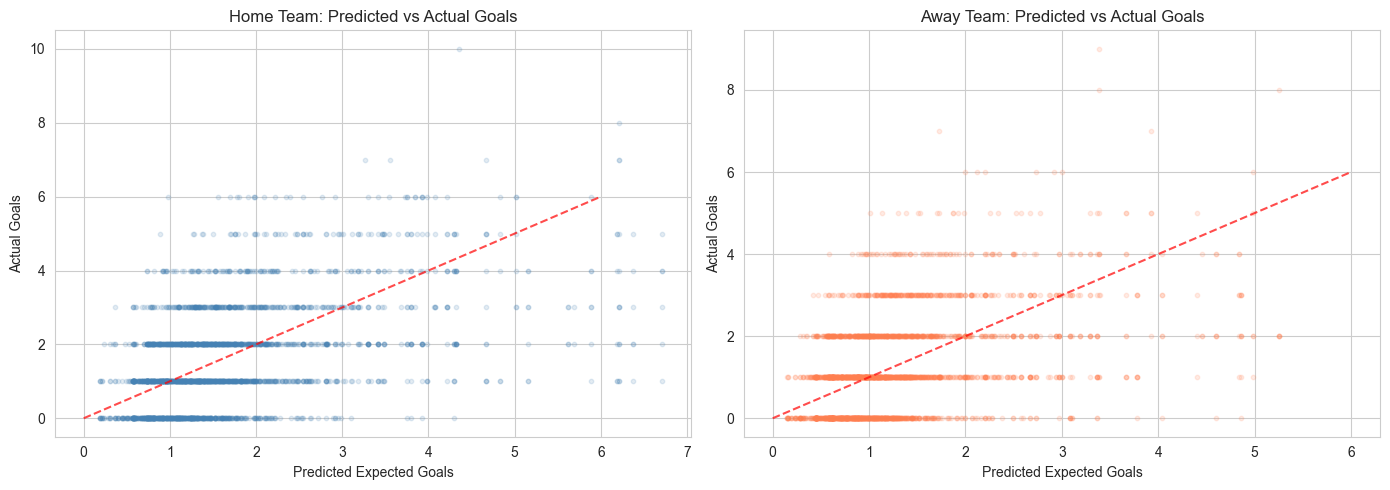

Home goal residuals: mean=-0.078, std=1.279
Away goal residuals: mean=-0.038, std=1.117


In [10]:
### === POISSON PREDICTED vs ACTUAL GOALS === ###

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Merge with actual scores
poisson_eval = poisson_df.merge(
    matches_df[['match_id', 'home_score', 'away_score']],
    on='match_id'
)

# Home goals: predicted vs actual
axes[0].scatter(poisson_eval['home_exp_goals'], poisson_eval['home_score'],
                alpha=0.15, s=10, color='steelblue')
axes[0].plot([0, 6], [0, 6], 'r--', alpha=0.7)
axes[0].set_xlabel('Predicted Expected Goals')
axes[0].set_ylabel('Actual Goals')
axes[0].set_title('Home Team: Predicted vs Actual Goals')

# Away goals: predicted vs actual
axes[1].scatter(poisson_eval['away_exp_goals'], poisson_eval['away_score'],
                alpha=0.15, s=10, color='coral')
axes[1].plot([0, 6], [0, 6], 'r--', alpha=0.7)
axes[1].set_xlabel('Predicted Expected Goals')
axes[1].set_ylabel('Actual Goals')
axes[1].set_title('Away Team: Predicted vs Actual Goals')

plt.tight_layout()
plt.show()

# Residual stats
home_resid = poisson_eval['home_score'] - poisson_eval['home_exp_goals']
away_resid = poisson_eval['away_score'] - poisson_eval['away_exp_goals']
print(f'Home goal residuals: mean={home_resid.mean():.3f}, std={home_resid.std():.3f}')
print(f'Away goal residuals: mean={away_resid.mean():.3f}, std={away_resid.std():.3f}')

---
## 5. Model Comparison Summary

Compare pre-match baselines against each other. These serve as the **minute-zero reference** for Nick's in-match models.

In [11]:
### === FINAL COMPARISON TABLE === ###

# Add Poisson model results to comparison
poisson_row = pd.DataFrame([{
    'Model': 'Poisson Goal Model',
    'Accuracy Mean': wl_correct.mean().round(3),
    'Accuracy StD': np.nan,
    'AUC Mean': poisson_auc.round(3),
    'AUC StD': np.nan,
}])

# Add naive baseline (always predict home win)
naive_acc = model_df[model_df['is_home'] == 1]['win'].mean()
naive_row = pd.DataFrame([{
    'Model': 'Naive Baseline (always home win)',
    'Accuracy Mean': round(naive_acc, 3),
    'Accuracy StD': np.nan,
    'AUC Mean': 0.5,
    'AUC StD': np.nan,
}])

all_results = pd.concat([naive_row, prematch_results, poisson_row], ignore_index=True)
print('=== PRE-MATCH BASELINE MODEL COMPARISON ===')
print('(Win/Loss only, draws excluded)')
print()
display(all_results)

=== PRE-MATCH BASELINE MODEL COMPARISON ===
(Win/Loss only, draws excluded)



,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,Naive Baseline (always home win),0.587,NaN,0.500,NaN
1,ELO diff only,0.687,0.034,0.763,0.031
2,ELO diff + Home,0.687,0.019,0.778,0.028
3,ELO diff + Home + Competition,0.688,0.019,0.778,0.028
4,ELO diff + Home + Year,0.687,0.019,0.778,0.028
5,Poisson Goal Model,0.743,NaN,0.824,NaN


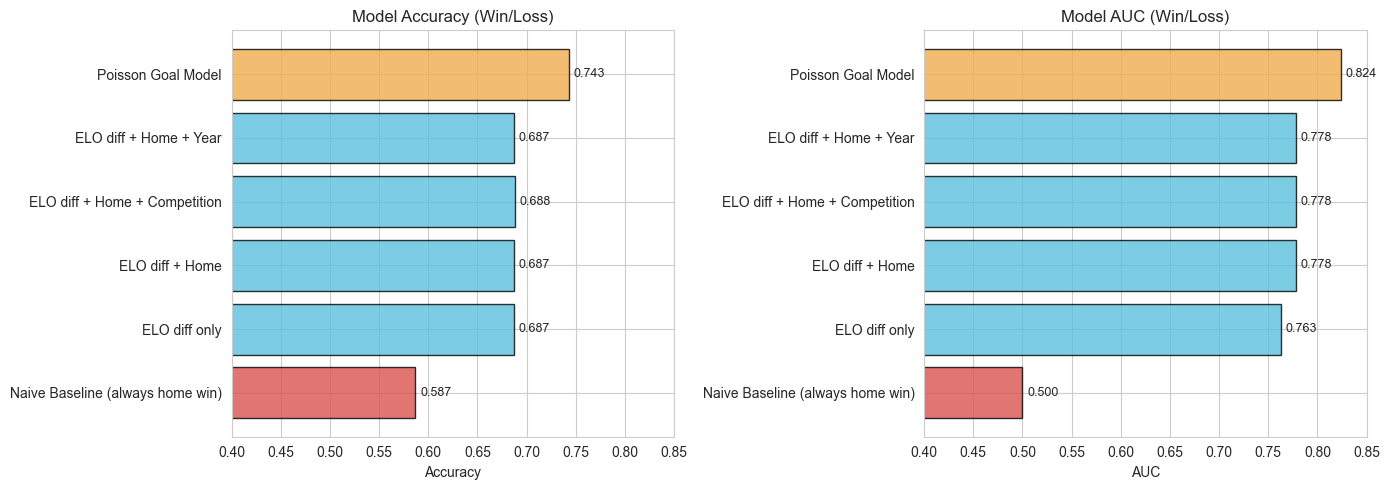


--- Key Takeaways ---
1. ELO diff alone provides a meaningful pre-match baseline
2. Home advantage adds predictive signal on top of ELO
3. Competition and year add minimal incremental value
4. Poisson model provides scoreline predictions, not just win/loss
5. These pre-match baselines set the floor that in-match models must beat


In [12]:
### === COMPARISON VISUALIZATION === ###

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
colors = ['#d9534f', '#5bc0de', '#5bc0de', '#5bc0de', '#5bc0de', '#f0ad4e']
axes[0].barh(all_results['Model'], all_results['Accuracy Mean'],
             color=colors, edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Accuracy (Win/Loss)')
axes[0].set_xlim(0.4, 0.85)
for i, v in enumerate(all_results['Accuracy Mean']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# AUC comparison
axes[1].barh(all_results['Model'], all_results['AUC Mean'],
             color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('AUC')
axes[1].set_title('Model AUC (Win/Loss)')
axes[1].set_xlim(0.4, 0.85)
for i, v in enumerate(all_results['AUC Mean']):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n--- Key Takeaways ---')
print('1. ELO diff alone provides a meaningful pre-match baseline')
print('2. Home advantage adds predictive signal on top of ELO')
print('3. Competition and year add minimal incremental value')
print('4. Poisson model provides scoreline predictions, not just win/loss')
print('5. These pre-match baselines set the floor that in-match models must beat')